## Experiment 02

## 1. Experiment Settings
- Sample size (n): 5000
- X1 dimension (d): 10
- X2 dimension (p): 500
- X1 and X2 are independent.
- Linear relationship between predictor (X2 only) and response (Y).
- Data were generated randomly 5 times to get 5 results from each model for analyzation.
- each model will be tuned only once.
- Use loop to run each model for one dataset.

In [1]:
import sys
sys.path.append("../src")

from generate_predictors import generate_predictors
from sklearn.model_selection import train_test_split

from models.lasso import tune_lasso
from models.lasso import fit_lasso

from models.ridge import tune_ridge
from models.ridge import fit_ridge

from models.random_forest import tune_random_forest
from models.random_forest import fit_random_forest

from models.neural_network import tune_neural_network
from models.neural_network import fit_neural_network

import numpy as np

## 2. Simulation

### Data Generation 1

In [2]:
np.random.seed(32)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
p = X2.shape[1]
rng = np.random.default_rng(seed=42)

n_active = int(p * 0.6)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta = np.zeros(p)

beta[active_indices] = rng.normal(
        0,
        1,
        n_active
    )

noise = rng.normal(0, 1, X2.shape[0])

Y = X2 @ beta + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

## Model Tuning

### Lasso Simulation 1

In [26]:
lasso_result = []
print(tune_lasso(X_train, Y_train, alphas = [0.05, 0.1, 0.5]))

{'best_alpha': 0.05, 'best_cv_mse': 2.1315473892849437, 'tuning_runtime': 0.768136200029403}


Smaller alpha gives smaller mse, but choosing much more variables.

In [27]:
l1 = fit_lasso(X_train, Y_train, X_test, Y_test, alpha=0.05)
lasso_result.append(l1)

### Ridge Simulation 1

In [ ]:
ridge_result = []
print(tune_ridge(X_train, Y_train, alphas=[0.1, 1.0, 1, 10]))

{'best_alpha': 0.05, 'best_cv_mse': 1.167072417977713, 'tuning_runtime': 1.1299966999795288}


In [25]:
r1 = fit_ridge(X_train, Y_train, X_test, Y_test, alpha=0.1)
ridge_result.append(r1)

### Random Forest Simulation 1

In [31]:
rf_result = []
print(tune_random_forest(
    X_train, Y_train, param_grid = {'n_estimators': [100], 'max_depth': [None, 20], "min_samples_leaf": [1, 5], "max_features": [0.5, 1.0]}, cv = 3))

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'best_params': {'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 5, 'n_estimators': 100}, 'best_cv_mse': 6378.232733659513, 'tuning_runtime': 392.8764325999655}


In [32]:
rf1 = fit_random_forest(
    X_train, Y_train, X_test, Y_test, params = {'n_estimators': 100, 'max_depth': None, "min_samples_leaf": 5, "max_features": 1.0})
rf_result.append(rf1)

### Neural Network Simulation 1

In [33]:
nn_result = []
print(tune_neural_network(X_train, Y_train, param_grid = {
    "hidden_layer_sizes": [(100,), (200,), (100, 50)],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
    "max_iter": [500]}))

Fitting 3 folds for each of 18 candidates, totalling 54 fits
{'best_params': {'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}, 'best_cv_mse': 50.02676770908331, 'tuning_runtime': 69.66491380007938}


In [34]:
nn1 = fit_neural_network(X_train, Y_train, X_test, Y_test, {"alpha": 0.01, "hidden_layer_sizes": (100,), "learning_rate_init": 0.01, "max_iter": 500})
nn_result.append(nn1)

### Data generation 2

In [35]:
np.random.seed(23)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
p = X2.shape[1]
rng = np.random.default_rng(seed=42)

n_active = int(p * 0.6)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta = np.zeros(p)

beta[active_indices] = rng.normal(
        0,
        1,
        n_active
    )

noise = rng.normal(0, 1, X2.shape[0])

Y = X2 @ beta + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Simulation 2 for all models

In [36]:
results = {
    "Lasso": lasso_result,
    "Ridge": ridge_result,
    "Random Forest": rf_result,
    "Neural Network": nn_result
}

models = {
    "Lasso": (
        fit_lasso,
        {"alpha": 0.05}
    ),
    "Ridge": (
        fit_ridge,
        {"alpha": 0.1}
    ),
    "Random Forest": (
        fit_random_forest,
        {"params": {'n_estimators': 100, 'max_depth': None, "min_samples_leaf": 5, "max_features": 1.0}}
    ),
    "Neural Network": (
        fit_neural_network,
        {"params": {'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 500}}
    )
}


for model_name, (fit_function, model_params) in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **model_params
    )

    results[model_name].append(result)

### Data Generation 3

In [37]:
np.random.seed(56)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
p = X2.shape[1]
rng = np.random.default_rng(seed=42)

n_active = int(p * 0.6)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta = np.zeros(p)

beta[active_indices] = rng.normal(
        0,
        1,
        n_active
    )

noise = rng.normal(0, 1, X2.shape[0])

Y = X2 @ beta + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Simulation 3 for all models

In [38]:
for model_name, (fit_function, model_params) in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **model_params
    )

    results[model_name].append(result)

### Data Generation 4

In [39]:
np.random.seed(44)

# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
p = X2.shape[1]
rng = np.random.default_rng(seed=42)

n_active = int(p * 0.6)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta = np.zeros(p)

beta[active_indices] = rng.normal(
        0,
        1,
        n_active
    )

noise = rng.normal(0, 1, X2.shape[0])

Y = X2 @ beta + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Simulation 4 for all models

In [40]:
for model_name, (fit_function, model_params) in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **model_params
    )

    results[model_name].append(result)

### Data Generation 5

In [42]:
np.random.seed(90)
# Configuration for predictors
X1_CONFIG = {
    "size": 5000,
    "dimension": 10,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 0,
        "std": 1
    }
}

X2_CONFIG = {
    "size": 5000,
    "dimension": 500,
    "variable_type": "continuous",
    "distribution": "normal",
    "distribution_params": {
        "mean": 2,
        "std": 5
    }
}

# Generate X1
X1 = generate_predictors(X1_CONFIG)

# Generate X2
X2 = generate_predictors(X2_CONFIG)

 # Generate noise
noise = np.random.normal(
    0,
    1,
    X1.shape[0]
    )
    
# Generate Y
p = X2.shape[1]
rng = np.random.default_rng(seed=42)

n_active = int(p * 0.6)

active_indices = rng.choice(
        p,
        size=n_active,
        replace=False
    )

beta = np.zeros(p)

beta[active_indices] = rng.normal(
        0,
        1,
        n_active
    )

noise = rng.normal(0, 1, X2.shape[0])

Y = X2 @ beta + noise
    
# Combine the feature matrices
X = np.hstack((X1, X2))

# Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
    )

### Simulation 5 for all models

In [43]:
for model_name, (fit_function, model_params) in models.items():

    result = fit_function(
        X_train,
        Y_train,
        X_test,
        Y_test,
        **model_params
    )

    results[model_name].append(result)

## 3. Evaluation

In [44]:
import pandas as pd
import matplotlib.pyplot as plt


def evaluate_mse(
    lasso_results,
    ridge_results,
    rf_results,
    nn_results
):
    results = {
        "Lasso": lasso_results,
        "Ridge": ridge_results,
        "Random Forest": rf_results,
        "Neural Network": nn_results
    }

    data = []

    for model_name, model_results in results.items():
        for repeat, result in enumerate(model_results, start=1):
            data.append({
                "model": model_name,
                "repeat": repeat,
                "mse": result["mse"]
            })

    df = pd.DataFrame(data)

    return df

In [45]:
mse_df = evaluate_mse(
    lasso_result,
    ridge_result,
    rf_result,
    nn_result
)

print(mse_df)

             model  repeat          mse
0            Lasso       1     2.127122
1            Lasso       2     2.103956
2            Lasso       3     2.021842
3            Lasso       4     2.112798
4            Lasso       5     2.098971
5            Ridge       1     1.133410
6            Ridge       2     1.133341
7            Ridge       3     1.133341
8            Ridge       4     1.133410
9            Ridge       5     1.133410
10           Ridge       6     1.164588
11           Ridge       7     1.144832
12           Ridge       8     1.242647
13           Ridge       9     1.221581
14   Random Forest       1  6060.277743
15   Random Forest       2  6169.739852
16   Random Forest       3  6540.231454
17   Random Forest       4  6134.537879
18   Random Forest       5  5940.767864
19  Neural Network       1    15.911958
20  Neural Network       2    14.997520
21  Neural Network       3    13.650465
22  Neural Network       4    14.264462
23  Neural Network       5    15.111159


In [46]:
average_mse = (
    mse_df
    .groupby("model")["mse"]
    .mean()
    .sort_values()
)

print(average_mse)

model
Ridge                1.160062
Lasso                2.092938
Neural Network      14.787113
Random Forest     6169.110958
Name: mse, dtype: float64


The plots are changed to log scale because Random Forest has significnatly larger mse.

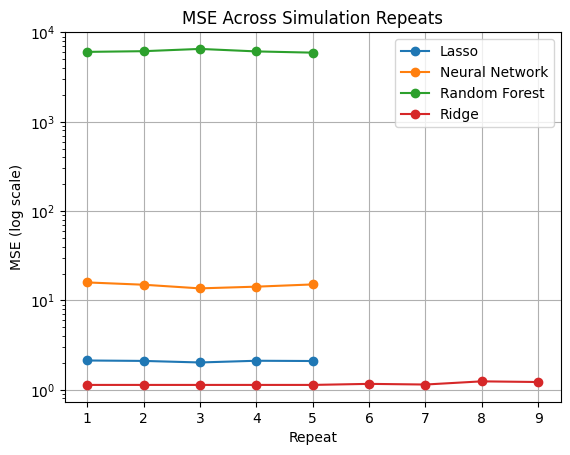

In [49]:
for model_name, group in mse_df.groupby("model"):
    plt.plot(
        group["repeat"],
        group["mse"],
        marker="o",
        label=model_name
    )

plt.xlabel("Repeat")
plt.ylabel("MSE (log scale)")
plt.title("MSE Across Simulation Repeats")
plt.yscale("log")
plt.legend()
plt.grid(True)
plt.show()

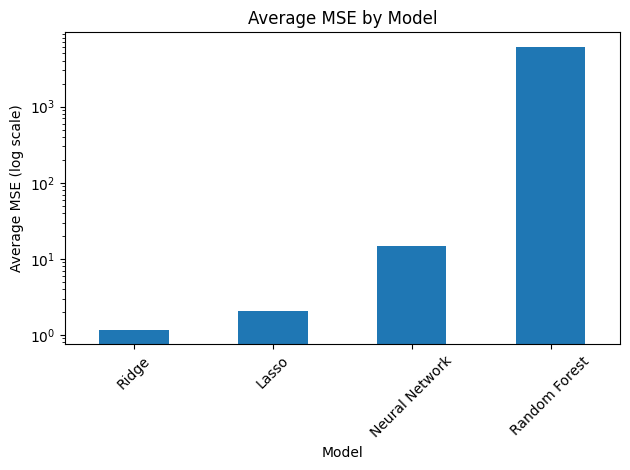

In [50]:
average_mse.plot(kind="bar")

plt.xlabel("Model")
plt.ylabel("Average MSE (log scale)")
plt.title("Average MSE by Model")
plt.yscale("log")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Conclusion 
Ridge achieved the lowest average MSE, followed by Lasso and the Neural Network, while Random Forest performed substantially worse. Compared with the sparse setting in Experiment 01, Ridge performed better than Lasso when the signal was distributed across a large number of predictors. This suggests that Ridge is better suited for dense linear relationships, whereas Lasso is more effective when the true signal is sparse. The poor performance of Random Forest may be due to its difficulty in capturing small additive effects distributed across many predictors.